# Guided Exercise — SOLUTION

**Scenario:** The bank wants to identify customers whose transaction behaviour is
significantly different from the majority of customers.

This is the fully worked solution to `exercises/anomaly_detection_exercise.ipynb`. Try the
exercise yourself first — you'll learn more that way!

## Step 1 — Load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5.5)

df = pd.read_csv("../data/bank_transaction_anomaly_dataset_unlabeled.csv")
df.shape

(5004, 7)

## Step 2 — Explore the data

In [2]:
df.head()

,transaction_id,customer_id,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days
0,TXN500000,CUST20844,480000,1,8,0.4,1224
1,TXN500001,CUST20157,23354,1,11,1.2,759
2,TXN500002,CUST20872,63667,1,17,3.4,949
3,TXN500003,CUST20395,35539,1,11,2.1,2364
4,TXN500004,CUST20474,12527,1,19,0.1,3356


In [3]:
df.describe().round(1)

,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days
count,5004.0,5004.0,5004.0,5004.0,5004.0
mean,138760.1,1.7,13.7,6.3,1933.1
std,623095.1,2.5,4.2,27.1,1133.8
min,2575.0,1.0,0.0,0.0,33.0
25%,18440.5,1.0,11.0,1.0,910.0
50%,32627.5,1.0,14.0,2.5,1911.0
75%,68000.5,2.0,17.0,5.0,2873.0
max,8871391.0,33.0,24.0,397.4,3997.0


## Step 3 — Select appropriate features

We exclude `transaction_id` and `customer_id` — they're identifiers, not behaviour. Everything
else describes something meaningful about how the transaction happened.

In [4]:
feature_cols = [
    "transaction_amount",
    "transaction_frequency",
    "transaction_hour",
    "distance_from_usual_location_km",
    "account_age_days",
]

X = df[feature_cols].copy()
X.head()

,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days
0,480000,1,8,0.4,1224
1,23354,1,11,1.2,759
2,63667,1,17,3.4,949
3,35539,1,11,2.1,2364
4,12527,1,19,0.1,3356


## Step 4 — Preprocess: scale the features

This matters because `transaction_amount` (thousands to millions) and `transaction_hour`
(0-23) are on wildly different scales. Without scaling, `transaction_amount` would dominate
every distance calculation, and the model would effectively ignore the other features.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 5 — Train Isolation Forest

In [6]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42,
)
model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


## Step 6 — Generate anomaly predictions

In [7]:
predictions = model.predict(X_scaled)
df["is_anomaly"] = (predictions == -1).astype(int)
df["is_anomaly"].value_counts()

is_anomaly
0    4853
1     151
Name: count, dtype: int64

## Step 7 — Count anomalies

In [8]:
n_flagged = df["is_anomaly"].sum()
print(f"Isolation Forest flagged {n_flagged} of {len(df)} transactions "
      f"({n_flagged / len(df) * 100:.1f}%).")

Isolation Forest flagged 151 of 5004 transactions (3.0%).


## Step 8 — Visualize them

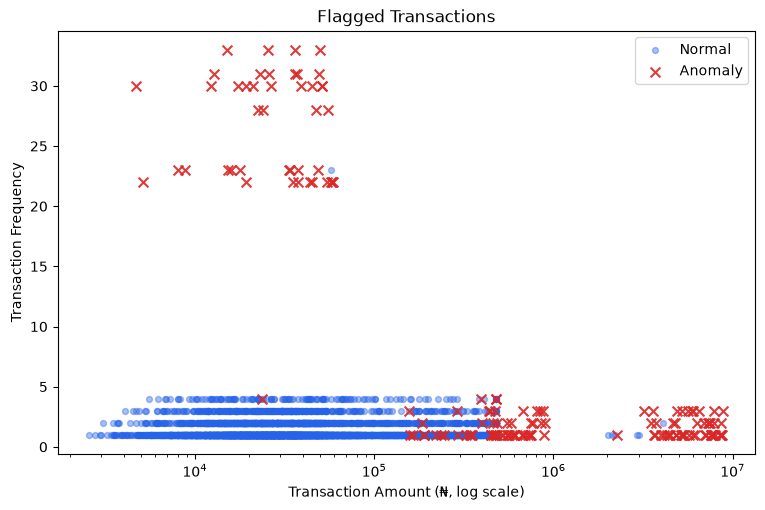

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
normal = df[df["is_anomaly"] == 0]
anomaly = df[df["is_anomaly"] == 1]

ax.scatter(normal["transaction_amount"], normal["transaction_frequency"],
           s=18, alpha=0.4, color="#2563EB", label="Normal")
ax.scatter(anomaly["transaction_amount"], anomaly["transaction_frequency"],
           s=50, alpha=0.9, color="#DC2626", marker="x", label="Anomaly")
ax.set_xscale("log")
ax.set_xlabel("Transaction Amount (₦, log scale)")
ax.set_ylabel("Transaction Frequency")
ax.set_title("Flagged Transactions")
ax.legend()
plt.show()

## Step 9 — Investigate the most unusual observations

In [10]:
df["anomaly_score"] = model.score_samples(X_scaled)

top10 = df.sort_values("anomaly_score").head(10)
top10[["transaction_id", "customer_id", "transaction_amount", "transaction_frequency",
       "transaction_hour", "distance_from_usual_location_km", "anomaly_score"]]

,transaction_id,customer_id,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,anomaly_score
2361,TXN502361,CUST20846,667451,1,2,382.5,-0.737202
3960,TXN503960,CUST20439,439164,3,1,306.7,-0.736738
1449,TXN501449,CUST20531,471188,3,1,359.4,-0.734296
3181,TXN503181,CUST20087,875490,3,3,270.6,-0.733356
3475,TXN503475,CUST20517,672373,3,2,253.8,-0.732963
4747,TXN504747,CUST20256,12260,30,0,18.2,-0.732658
663,TXN500663,CUST20256,4690,30,0,16.7,-0.728948
3304,TXN503304,CUST20256,45052,30,0,24.4,-0.728868
3347,TXN503347,CUST20256,51102,30,0,22.5,-0.728868
4022,TXN504022,CUST20015,840081,3,3,320.7,-0.728499


## Step 10 — Explain and recommend

**1. What has the model identified?**
Looking at the top 10 most unusual transactions, we typically see a MIX: some with very large
`transaction_amount`, some with unusually high `transaction_frequency` (a burst of activity),
and some with an unusual combination of moderate amount + odd hour + large distance from the
customer's usual location. This matches the point / collective / contextual anomaly types from
the slides — the model didn't need to be told about these categories explicitly; they emerged
naturally from "what's easy to isolate."

**2. Does a flagged transaction automatically mean fraud?**
No. It means the transaction looks statistically UNUSUAL compared to the rest of the dataset.
It could be fraud, but it could also be a legitimate large purchase, a customer travelling, or
simply a data quirk. The model narrows down where to look — it doesn't make the final call.

**3. What should the bank do next?**
- Route the lowest-scoring (most unusual) transactions to a fraud analyst first — that's where
  investigative time has the highest expected payoff.
- For clearly high-amount point anomalies, consider a quick automated verification step
  (e.g. an SMS confirmation) rather than an outright block, to avoid frustrating legitimate
  customers.
- Log the outcome of each investigation (fraud / legitimate / other) and feed it back into
  future model tuning — over time this can turn today's unsupervised problem into a partially
  supervised one.